# notebooks/03_model_building.ipynb

In [138]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

## Load Model-Ready Data

In [139]:
DATA_PATH = os.path.join('..', 'data', 'panel_data_model_ready.parquet')

df = pd.read_parquet(DATA_PATH)
print(f'Data Shape: {df.shape}')
display(df.head())

Data Shape: (153515, 19)


rv       bpv      good       bad         rq    vix  \
Date       Stock                                                             
2003-01-03 AAPL   6.574494  5.893317  3.638035  2.936459  62.054316  24.68   
           AMGN   3.225009  3.043199  1.961131  1.263879  31.538602  24.68   
           AMZN   5.290480  4.212468  3.812314  1.478167  61.555140  24.68   
           AXP    3.394580  3.409980  1.725383  1.669197  13.330858  24.68   
           BA     3.064001  3.755029  1.403990  1.660010  13.424943  24.68   

                     Y_reg  rv_lag_1  rv_rolling_5  rv_rolling_22  bpv_lag_1  \
Date       Stock                                                               
2003-01-03 AAPL   5.992264  6.493909      6.493909       6.493909   3.771960   
           AMGN   2.460476  5.177506      5.177506       5.177506   3.635898   
           AMZN   5.818162  9.886836      9.886836       9.886836   8.018926   
           AXP    4.693210  4.448244      4.448244       4.448244   4.122573   
           BA     2.934207  7.469396      7.469396       7.469396   7.016747   

                  bpv_rolling_5  good_lag_1  bad_lag_1  bad_lag_5    rq_lag_1  \
Date       Stock                                                                
2003-01-03 AAPL        3.771960    5.102315   1.391595   2.164027  152.729402   
           AMGN        3.635898    3.362921   1.814585   1.539232   46.168213   
           AMZN        8.018926    6.074276   3.812559   2.645363  200.751309   
           AXP         4.122573    3.337253   1.110991   1.390094  114.695371   
           BA          7.016747    5.107386   2.362010   2.011010  150.112379   

                  vix_lag_1  rv_vix_interaction  bad_rv_interaction  
Date       Stock                                                     
2003-01-03 AAPL       25.39          164.880356            9.036889  
           AMGN       25.39          131.456870            9.395025  
           AMZN       25.39          251.026754           37.694144  
           AXP        25.39          112.940920            4.941961  
           BA         25.39          189.647958           17.642785

## Define Features (X) and Target (Y)

In [140]:
Y = df['Y_reg']

har_features = ['rv_lag_1', 'rv_rolling_5', 'rv_rolling_22']
X_har = df[har_features]

X_advanced = df.drop(columns=['rv', 'bpv', 'good', 'bad', 'rq', 'vix', 'Y_reg'])

print(f'Target (Y) shape: {Y.shape}')
print(f'HAR Features (X_har) shape: {X_har.shape}')
print(f'Advanced Features (X_advanced) shape: {X_advanced.shape}')
display(X_har.head())

Target (Y) shape: (153515,)
HAR Features (X_har) shape: (153515, 3)
Advanced Features (X_advanced) shape: (153515, 12)


rv_lag_1  rv_rolling_5  rv_rolling_22
Date       Stock                                       
2003-01-03 AAPL   6.493909      6.493909       6.493909
           AMGN   5.177506      5.177506       5.177506
           AMZN   9.886836      9.886836       9.886836
           AXP    4.448244      4.448244       4.448244
           BA     7.469396      7.469396       7.469396

## Setup Rolling Window Validation

Initialized TimeSeriesSplit with 2 splits.


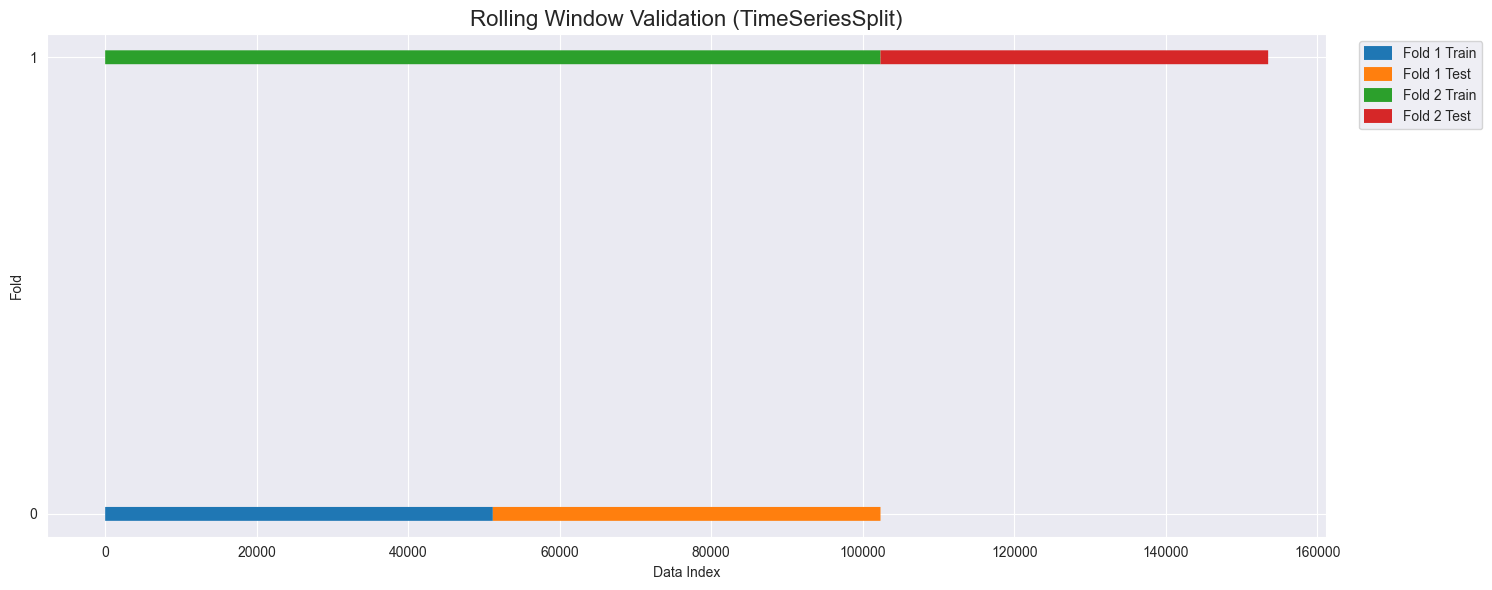

In [141]:
N_SPLITS = 2
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

print(f'Initialized TimeSeriesSplit with {N_SPLITS} splits.')

fig, ax = plt.subplots(figsize=(15, 6))
for i, (train_index, test_index) in enumerate(tscv.split(X_har)):
    ax.plot(train_index, [i] * len(train_index), label=f'Fold {i+1} Train', lw=10, solid_capstyle='butt')
    ax.plot(test_index, [i] * len(test_index), label=f'Fold {i+1} Test', lw=10, solid_capstyle='butt')

ax.set_title('Rolling Window Validation (TimeSeriesSplit)', fontsize=16)
ax.set_xlabel('Data Index')
ax.set_ylabel('Fold')
ax.set_yticks(range(N_SPLITS))
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Train & Evaluate HAR Baseline

In [142]:
# ============================================================
# HAR Baseline (Reproducible & Independent of Extra Features)
# ============================================================

print("\nPreparing clean HAR baseline dataset...")

# HAR feature list
har_features = ['rv_lag_1', 'rv_rolling_5', 'rv_rolling_22']

# Construct a clean DataFrame containing ONLY HAR features + target
df_har = df[har_features + ['Y_reg']].dropna().copy()

print("HAR dataset size:", df_har.shape)

# Separate X and Y
X_har = df_har[har_features]
Y = df_har['Y_reg']

# Log-log transform
Y_log = np.log1p(Y)
X_har_log = np.log1p(X_har)

har_mse_scores_log = []
har_models_log = []

print('\nTraining & Evaluation for HAR (Log-Log Specification)...')

for i, (train_index, test_index) in enumerate(tscv.split(X_har_log)):
    print(f'--- Fold {i+1}/{N_SPLITS} ---')
    
    X_train, X_test = X_har_log.iloc[train_index], X_har_log.iloc[test_index]
    y_train_log, y_test_log = Y_log.iloc[train_index], Y_log.iloc[test_index]
    
    print(f"  Train size: {len(X_train)}, Test size: {len(X_test)}")
    
    har_model_log = LinearRegression()
    har_model_log.fit(X_train, y_train_log)
    
    y_pred_log = har_model_log.predict(X_test)
    
    # Convert back to original scale
    y_test_orig = np.expm1(y_test_log)
    y_pred_orig = np.expm1(y_pred_log)
    y_pred_orig[y_pred_orig < 0] = 0
    
    # Compute MSE
    mse = mean_squared_error(y_test_orig, y_pred_orig)
    
    har_mse_scores_log.append(mse)
    har_models_log.append(har_model_log)
    
    print(f"  Fold {i+1} MSE (Original Scale): {mse:.6f}")

# Average MSE
average_har_mse_log = np.mean(har_mse_scores_log)
print(f"\nAverage HAR Model MSE (Log-Log Trained): {average_har_mse_log:.6f}")



Preparing clean HAR baseline dataset...
HAR dataset size: (153515, 4)

Training & Evaluation for HAR (Log-Log Specification)...
--- Fold 1/2 ---
  Train size: 51173, Test size: 51171
  Fold 1 MSE (Original Scale): 4.912242
--- Fold 2/2 ---
  Train size: 102344, Test size: 51171
  Fold 2 MSE (Original Scale): 14.973623

Average HAR Model MSE (Log-Log Trained): 9.942932


In [143]:
import joblib
MODEL_PATH = os.path.join("..", "models")

final_har_model = har_models_log[-1]
har_model_filename = os.path.join(MODEL_PATH, "har_baseline_model.joblib")
joblib.dump(final_har_model, har_model_filename)

print(f"Final HAR model saved to: {har_model_filename}")

Final HAR model saved to: ..\models\har_baseline_model.joblib


## Isolation Forest Part

In [144]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [145]:
MODEL_PATH = os.path.join("..", "models", "har_baseline_model.joblib")

har_model = joblib.load(MODEL_PATH)

har_features = ['rv_lag_1', 'rv_rolling_5', 'rv_rolling_22']
X_har = df[har_features]
Y_reg = df['Y_reg']

## Calculate Model Residuals (Errors)

In [146]:
har_predictions = har_model.predict(X_har)
df['har_error'] = Y_reg - har_predictions
print("HAR model residuals calculated.")
display(df[['Y_reg', 'har_error']].describe())

HAR model residuals calculated.


,Y_reg,har_error
count,153515.000000,153515.000000
mean,2.315558,0.165175
std,5.565324,4.210541
min,0.045685,-129.044338
25%,0.677630,-0.450093
50%,1.184212,-0.105003
75%,2.213203,0.336355
max,400.349507,349.902160


## Standardize Residuals

In [147]:
scaler = StandardScaler()
df['error_scaled'] = df.groupby(level='Stock')['har_error'].transform(lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten())

print("Residuals have been standardized per stock.")
display(df[['har_error', 'error_scaled']].head())

Residuals have been standardized per stock.


har_error  error_scaled
Date       Stock                         
2003-01-03 AAPL    0.092520     -0.033875
           AMGN   -2.256294     -0.783057
           AMZN   -3.130603     -0.866341
           AXP     0.631783      0.070413
           BA     -3.842149     -0.673634

## Train the Isolation Forest

In [148]:
train_end_date = '2019-12-31'
train_data = df.loc[df.index.get_level_values('Date') <= train_end_date]

X_train_errors = train_data['error_scaled'].values.reshape(-1, 1)
print(f"Training Isolation Forest on {len(X_train_errors)} data points...")

iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(X_train_errors)

Training Isolation Forest on 121535 data points...


,n_estimators,100
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


## Create Anomaly Labels (Y_class)

In [149]:
X_all_errors = df['error_scaled'].values.reshape(-1, 1)

anomaly_predictions = iso_forest.predict(X_all_errors)

df['is_abnormal'] = np.where(anomaly_predictions == -1, 1, 0)

abnormal_pct = df['is_abnormal'].mean() * 100
print(f"Total anomalies detected across all data: {df['is_abnormal'].sum()}")
print(f"Percentage of anomalies: {abnormal_pct:.2f}%")

display(df[['har_error', 'error_scaled', 'is_abnormal']].head())

Total anomalies detected across all data: 8205
Percentage of anomalies: 5.34%


har_error  error_scaled  is_abnormal
Date       Stock                                      
2003-01-03 AAPL    0.092520     -0.033875            0
           AMGN   -2.256294     -0.783057            0
           AMZN   -3.130603     -0.866341            0
           AXP     0.631783      0.070413            0
           BA     -3.842149     -0.673634            0

## Visualize and Validate the Anomalies

Anomalies found for AAPL: 422


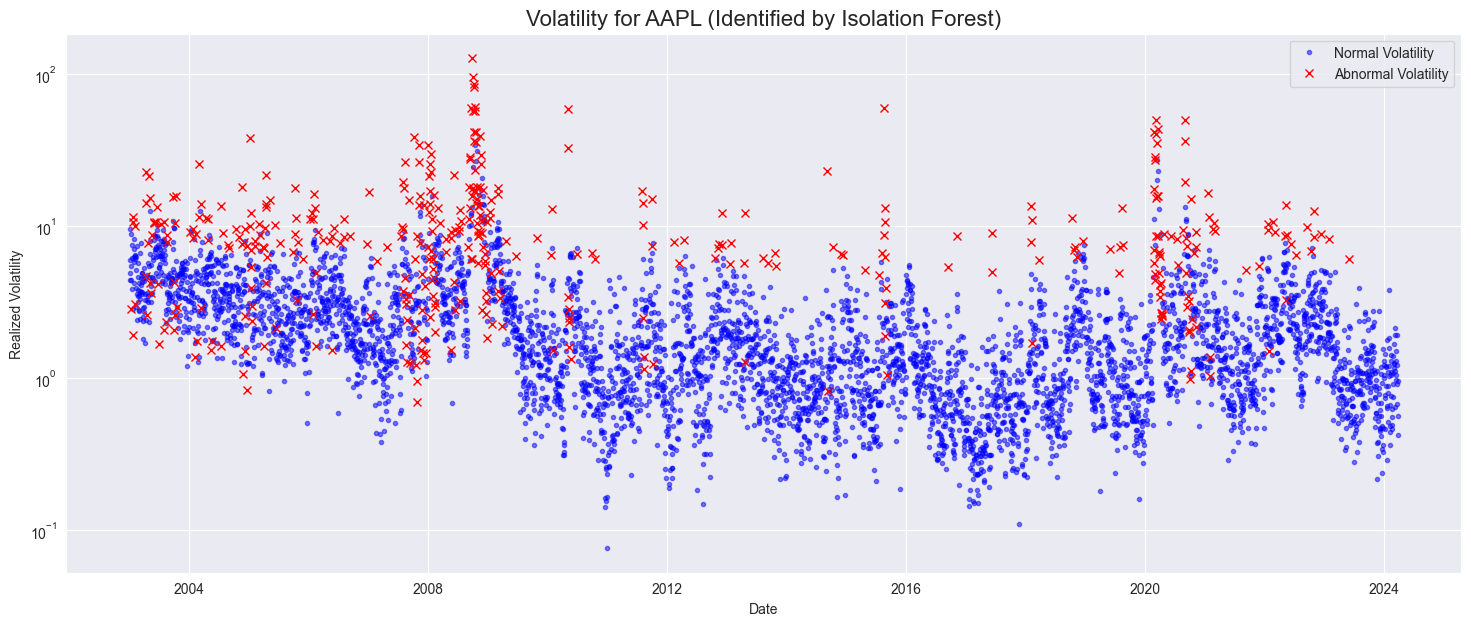

In [150]:
stock_to_plot = 'AAPL'
df_stock = df.loc[pd.IndexSlice[:, stock_to_plot], :]

anomalies = df_stock[df_stock['is_abnormal'] == 1]
normals = df_stock[df_stock['is_abnormal'] == 0]

print(f"Anomalies found for {stock_to_plot}: {len(anomalies)}")

plt.figure(figsize=(18, 7))
plt.plot(
    normals.index.get_level_values('Date'), 
    normals['Y_reg'], 
    linestyle='None', 
    marker='.', 
    color='blue', 
    alpha=0.5, 
    label='Normal Volatility'
)
plt.plot(
    anomalies.index.get_level_values('Date'), 
    anomalies['Y_reg'], 
    linestyle='None', 
    marker='x', 
    color='red', 
    label='Abnormal Volatility'
)

plt.title(f'Volatility for {stock_to_plot} (Identified by Isolation Forest)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Realized Volatility')
plt.legend()
plt.yscale('log')
plt.show()

In [160]:
df = df.reset_index()

df['Y_class'] = df.groupby('Stock')['is_abnormal'].shift(-1)

df['jump_share'] = (df['rv'] - df['bpv']) / (df['rv'] + 1e-6)
df['jump_share'] = df['jump_share'].clip(lower=0)  
df['jump_share_rolling_5'] = (
    df.groupby('Stock')['jump_share']
      .rolling(5).mean()
      .reset_index(level=0, drop=True)
)

df['downside_share'] = df['bad'] / (df['good'] + df['bad'] + 1e-6)

df['kurtosis_proxy'] = df['rq'] / ((df['rv'] + 1e-6) ** 2)

df['vol_of_vol_10'] = (
    df.groupby('Stock')['rv']
      .rolling(window=10).std()
      .reset_index(level=0, drop=True)
)

df['vol_of_vol_5'] = (
    df.groupby('Stock')['rv']
      .rolling(window=5).std()
      .reset_index(level=0, drop=True)
)

df['vix_zscore_22'] = (
    df['vix'] -
    df.groupby('Stock')['vix'].rolling(22).mean().reset_index(level=0, drop=True)
) / (
    df.groupby('Stock')['vix'].rolling(22).std().reset_index(level=0, drop=True) + 1e-6
)

df['abnormal_share_10'] = (
    df.groupby('Stock')['is_abnormal']
      .rolling(10, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)
)

df['abnormal_share_3'] = (
    df.groupby('Stock')['is_abnormal']
      .rolling(3, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)
)

abn10 = (
    df.groupby('Stock')['is_abnormal']
      .rolling(10)
      .mean()
      .reset_index(level=0, drop=True)
)

df['abnormal_slope_10'] = abn10.groupby(df['Stock']).diff()

def rolling_cluster_count(series, window=20):
    rolled = series.rolling(window)
    return rolled.apply(lambda x: ((x > 0).astype(int).diff().abs().sum() + (x.iloc[0] > 0)) // 2)

df['abnormal_cluster_20'] = (
    df.groupby('Stock')['is_abnormal']
      .apply(lambda s: rolling_cluster_count(s, 20))
      .reset_index(level=0, drop=True)
)

df = df.set_index(['Date', 'Stock'])

df_model_ready_phase4 = df.dropna()

output_path = os.path.join("..", "data", "panel_data_phase4_ready.parquet")
df_model_ready_phase4.to_parquet(output_path)
display(df_model_ready_phase4.head())


rv       bpv      good       bad         rq    vix  \
Date       Stock                                                             
2003-03-04 AAPL   2.800030  2.908662  1.040734  1.759297  13.217712  31.83   
           AMGN   1.397009  1.298808  0.796190  0.600819   3.255164  31.83   
           AMZN   2.376120  2.282922  1.747135  0.628985   6.488344  31.83   
           AXP    1.397395  1.481738  0.502886  0.894508   1.680120  31.83   
           BA     3.761680  2.274409  1.982930  1.778750  28.349637  31.83   

                     Y_reg  rv_lag_1  rv_rolling_5  rv_rolling_22  ...  \
Date       Stock                                                   ...   
2003-03-04 AAPL   4.235857  3.512468      3.854032       5.075757  ...   
           AMGN   1.968257  1.749890      2.091108       2.427743  ...   
           AMZN   3.482232  6.545382      4.459603       4.736682  ...   
           AXP    1.903712  1.793315      2.982122       4.262840  ...   
           BA     6.043311  2.162261      3.540270       4.662661  ...   

                  abnormal_share_3  abnormal_slope_10  abnormal_cluster_20  \
Date       Stock                                                             
2003-03-04 AAPL                0.0                0.0                  2.0   
           AMGN                0.0                0.0                  0.0   
           AMZN                0.0               -0.1                  2.0   
           AXP                 0.0                0.0                  1.0   
           BA                  0.0                0.0                  0.0   

                  jump_share  jump_share_rolling_5  downside_share  \
Date       Stock                                                     
2003-03-04 AAPL     0.000000              0.129242        0.628313   
           AMGN     0.070294              0.160635        0.430075   
           AMZN     0.039223              0.135041        0.264711   
           AXP      0.000000              0.053257        0.640125   
           BA       0.395374              0.079075        0.472860   

                  kurtosis_proxy  vol_of_vol_10  vol_of_vol_5  vix_zscore_22  
Date       Stock                                                              
2003-03-04 AAPL         1.685895       0.963287      1.187663      -0.175383  
           AMGN         1.667915       0.619817      0.634668      -0.175383  
           AMZN         1.149203       1.945858      2.473389      -0.175383  
           AXP          0.860402       1.108137      0.817027      -0.175383  
           BA           2.003473       1.674886      0.938864      -0.175383  

[5 rows x 34 columns]

## Advanced ML Modeling & Interpretation

In [161]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import shap

import warnings
warnings.filterwarnings('ignore')

In [162]:
print("Loaded advanced modeling libraries (XGBoost, SHAP).")

PHASE_4_DATA_PATH = os.path.join('..', 'data', 'panel_data_phase4_ready.parquet')
df = pd.read_parquet(PHASE_4_DATA_PATH)

print(f"Loaded Phase 4 data: {df.shape}")
display(df.head())

Loaded advanced modeling libraries (XGBoost, SHAP).
Loaded Phase 4 data: (152255, 34)


rv       bpv      good       bad         rq    vix  \
Date       Stock                                                             
2003-03-04 AAPL   2.800030  2.908662  1.040734  1.759297  13.217712  31.83   
           AMGN   1.397009  1.298808  0.796190  0.600819   3.255164  31.83   
           AMZN   2.376120  2.282922  1.747135  0.628985   6.488344  31.83   
           AXP    1.397395  1.481738  0.502886  0.894508   1.680120  31.83   
           BA     3.761680  2.274409  1.982930  1.778750  28.349637  31.83   

                     Y_reg  rv_lag_1  rv_rolling_5  rv_rolling_22  ...  \
Date       Stock                                                   ...   
2003-03-04 AAPL   4.235857  3.512468      3.854032       5.075757  ...   
           AMGN   1.968257  1.749890      2.091108       2.427743  ...   
           AMZN   3.482232  6.545382      4.459603       4.736682  ...   
           AXP    1.903712  1.793315      2.982122       4.262840  ...   
           BA     6.043311  2.162261      3.540270       4.662661  ...   

                  abnormal_share_3  abnormal_slope_10  abnormal_cluster_20  \
Date       Stock                                                             
2003-03-04 AAPL                0.0                0.0                  2.0   
           AMGN                0.0                0.0                  0.0   
           AMZN                0.0               -0.1                  2.0   
           AXP                 0.0                0.0                  1.0   
           BA                  0.0                0.0                  0.0   

                  jump_share  jump_share_rolling_5  downside_share  \
Date       Stock                                                     
2003-03-04 AAPL     0.000000              0.129242        0.628313   
           AMGN     0.070294              0.160635        0.430075   
           AMZN     0.039223              0.135041        0.264711   
           AXP      0.000000              0.053257        0.640125   
           BA       0.395374              0.079075        0.472860   

                  kurtosis_proxy  vol_of_vol_10  vol_of_vol_5  vix_zscore_22  
Date       Stock                                                              
2003-03-04 AAPL         1.685895       0.963287      1.187663      -0.175383  
           AMGN         1.667915       0.619817      0.634668      -0.175383  
           AMZN         1.149203       1.945858      2.473389      -0.175383  
           AXP          0.860402       1.108137      0.817027      -0.175383  
           BA           2.003473       1.674886      0.938864      -0.175383  

[5 rows x 34 columns]

In [163]:
Y_reg = df['Y_reg']
Y_reg_log = np.log1p(Y_reg)

Y_class = df['Y_class']

non_feature_cols = [
    'rv', 'bpv', 'good', 'bad', 'rq', 'vix',
    'Y_reg',                                 
    'har_error', 'error_scaled', 'is_abnormal',
    'Y_class'                               
]
X_advanced = df.drop(columns=non_feature_cols)
X_advanced_log = np.log1p(X_advanced)

print(f"Advanced Features (X_advanced) shape: {X_advanced.shape}")
print(f"Regression Target (Y_reg) shape: {Y_reg.shape}")
print(f"Classification Target (Y_class) shape: {Y_class.shape}")
display(X_advanced.head())

Advanced Features (X_advanced) shape: (152255, 23)
Regression Target (Y_reg) shape: (152255,)
Classification Target (Y_class) shape: (152255,)


rv_lag_1  rv_rolling_5  rv_rolling_22  bpv_lag_1  \
Date       Stock                                                     
2003-03-04 AAPL   3.512468      3.854032       5.075757   2.670078   
           AMGN   1.749890      2.091108       2.427743   1.327514   
           AMZN   6.545382      4.459603       4.736682   6.072385   
           AXP    1.793315      2.982122       4.262840   1.816144   
           BA     2.162261      3.540270       4.662661   2.334969   

                  bpv_rolling_5  good_lag_1  bad_lag_1  bad_lag_5   rq_lag_1  \
Date       Stock                                                               
2003-03-04 AAPL        3.392347    0.919349   2.593119   2.095137  25.753981   
           AMGN        1.882592    0.573817   1.176073   0.849153   5.818387   
           AMZN        3.945551    3.046024   3.499357   1.812954  92.418217   
           AXP         2.654568    0.581237   1.212078   1.172404   4.529710   
           BA          3.641286    0.617281   1.544980   2.019062   7.555429   

                  vix_lag_1  ...  abnormal_share_3  abnormal_slope_10  \
Date       Stock             ...                                        
2003-03-04 AAPL       30.43  ...               0.0                0.0   
           AMGN       30.43  ...               0.0                0.0   
           AMZN       30.43  ...               0.0               -0.1   
           AXP        30.43  ...               0.0                0.0   
           BA         30.43  ...               0.0                0.0   

                  abnormal_cluster_20  jump_share  jump_share_rolling_5  \
Date       Stock                                                          
2003-03-04 AAPL                   2.0    0.000000              0.129242   
           AMGN                   0.0    0.070294              0.160635   
           AMZN                   2.0    0.039223              0.135041   
           AXP                    1.0    0.000000              0.053257   
           BA                     0.0    0.395374              0.079075   

                  downside_share  kurtosis_proxy  vol_of_vol_10  vol_of_vol_5  \
Date       Stock                                                                
2003-03-04 AAPL         0.628313        1.685895       0.963287      1.187663   
           AMGN         0.430075        1.667915       0.619817      0.634668   
           AMZN         0.264711        1.149203       1.945858      2.473389   
           AXP          0.640125        0.860402       1.108137      0.817027   
           BA           0.472860        2.003473       1.674886      0.938864   

                  vix_zscore_22  
Date       Stock                 
2003-03-04 AAPL       -0.175383  
           AMGN       -0.175383  
           AMZN       -0.175383  
           AXP        -0.175383  
           BA         -0.175383  

[5 rows x 23 columns]

In [164]:
## --- Setup Validation ---
N_SPLITS = 2
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

## XGBoost

In [165]:
print("--- Starting Task 4.1: Advanced Regression (XGBoost) ---")

X_train_data = X_advanced 
y_train_data = Y_reg_log

xgb_reg_mse_scores = []
xgb_reg_models = []

for i, (train_index, test_index) in enumerate(tscv.split(X_train_data)):
    print(f'--- Fold {i+1}/{N_SPLITS} ---')

    X_train, X_test = X_train_data.iloc[train_index], X_train_data.iloc[test_index]
    y_train_log, y_test_log = y_train_data.iloc[train_index], y_train_data.iloc[test_index]
    
    print(f"  Train size: {len(X_train)}, Test size: {len(X_test)}")
    
    xgb_reg = xgb.XGBRegressor(
        objective='reg:squarederror',
        max_depth=4,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.9,
        n_estimators=350,
        learning_rate=0.04,
        random_state=42,
        n_jobs=-1
    )
    
    xgb_reg.fit(X_train, y_train_log)
    
    y_pred_log = xgb_reg.predict(X_test)
    y_test_orig = np.expm1(y_test_log)
    y_pred_orig = np.expm1(y_pred_log)
    
    y_pred_orig[y_pred_orig < 0] = 0 
    
    mse = mean_squared_error(y_test_orig, y_pred_orig)
    xgb_reg_mse_scores.append(mse)
    xgb_reg_models.append(xgb_reg)
    
    print(f"  Fold {i+1} MSE (Original Scale): {mse:.6f}")

avg_xgb_mse = np.mean(xgb_reg_mse_scores)

print("\n--- Regression Model Comparison ---")
print(f"  Average HAR Model MSE (Log-Log):     {average_har_mse_log:.6f}")
print(f"  Average XGB Regressor MSE:           {avg_xgb_mse:.6f}")

improvement = (average_har_mse_log - avg_xgb_mse) / average_har_mse_log
print(f"\n  Improvement over HAR: {improvement:.2%}")

--- Starting Task 4.1: Advanced Regression (XGBoost) ---
--- Fold 1/2 ---
  Train size: 50753, Test size: 50751
  Fold 1 MSE (Original Scale): 3.936459
--- Fold 2/2 ---
  Train size: 101504, Test size: 50751
  Fold 2 MSE (Original Scale): 12.542788

--- Regression Model Comparison ---
  Average HAR Model MSE (Log-Log):     9.942932
  Average XGB Regressor MSE:           8.239624

  Improvement over HAR: 17.13%


## Anomaly Classification (XGBoost)


--- Starting Task 4.2: Anomaly Classification (XGBoost + Dual Threshold Display) ---
--- Fold 1/2 ---
  Train size: 50753, Test size: 50751
  Train Abnormal Pct: 8.52%, Test Abnormal Pct: 2.18%
  Calculated scale_pos_weight: 10.74
--- Fold 2/2 ---
  Train size: 101504, Test size: 50751
  Train Abnormal Pct: 5.35%, Test Abnormal Pct: 5.18%
  Calculated scale_pos_weight: 17.70

================ Threshold = 0.50 ================

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.98      0.90      0.94     48121
Abnormal (1)       0.27      0.68      0.39      2630

    accuracy                           0.89     50751
   macro avg       0.63      0.79      0.66     50751
weighted avg       0.94      0.89      0.91     50751



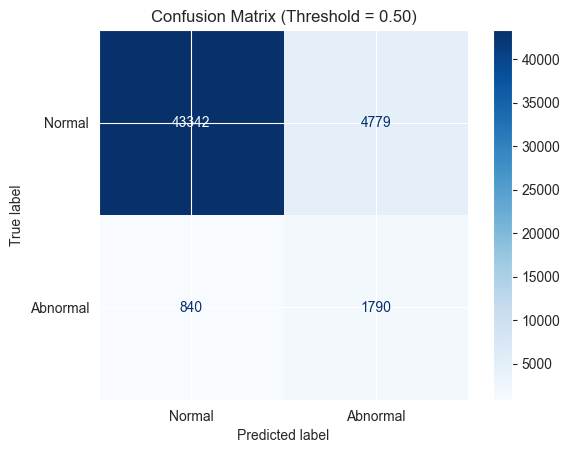


================ Threshold = 0.75 ================

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.98      0.97      0.97     48121
Abnormal (1)       0.49      0.55      0.52      2630

    accuracy                           0.95     50751
   macro avg       0.73      0.76      0.74     50751
weighted avg       0.95      0.95      0.95     50751



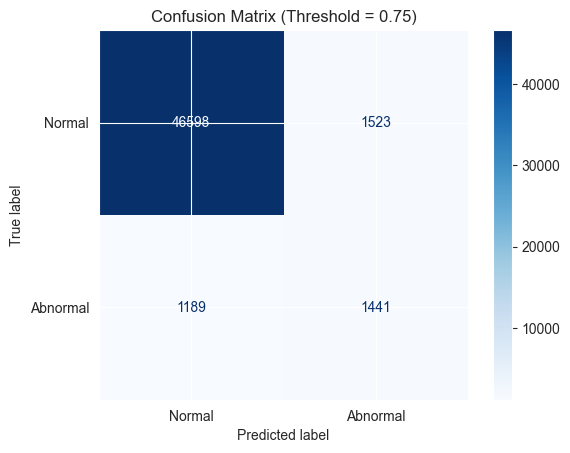

In [166]:
print("\n--- Starting Task 4.2: Anomaly Classification (XGBoost + Dual Threshold Display) ---")

xgb_class_models = []
last_fold_data = {}

FINAL_THRESHOLDS = [0.50, 0.75]

for i, (train_index, test_index) in enumerate(tscv.split(X_advanced)):
    print(f'--- Fold {i+1}/{N_SPLITS} ---')
    
    X_train, X_test = X_advanced.iloc[train_index], X_advanced.iloc[test_index]
    y_train, y_test = Y_class.iloc[train_index], Y_class.iloc[test_index]
    
    print(f"  Train size: {len(X_train)}, Test size: {len(X_test)}")
    print(f"  Train Abnormal Pct: {y_train.mean():.2%}, Test Abnormal Pct: {y_test.mean():.2%}")

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    print(f"  Calculated scale_pos_weight: {scale_pos_weight:.2f}")

    xgb_class = xgb.XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=scale_pos_weight,
        max_depth=5,
        min_child_weight=5,
        subsample=0.9,
        colsample_bytree=0.9,
        n_estimators=400,
        learning_rate=0.04,
        random_state=42,
        n_jobs=-1,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    
    xgb_class.fit(X_train, y_train)


    y_prob = xgb_class.predict_proba(X_test)[:, 1]


    if i == N_SPLITS - 1:
        last_fold_data['X_test'] = X_test
        last_fold_data['y_test'] = y_test
        last_fold_data['y_prob'] = y_prob
        xgb_class_models.append(xgb_class)


y_test = last_fold_data['y_test']
y_prob = last_fold_data['y_prob']

for th in FINAL_THRESHOLDS:
    print(f"\n================ Threshold = {th:.2f} ================")
    
    y_pred = (y_prob >= th).astype(int)
    
    print("\nClassification Report:")
    print(classification_report(
        y_test, y_pred, 
        target_names=['Normal (0)', 'Abnormal (1)']
    ))
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Normal', 'Abnormal']
    )
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix (Threshold = {th:.2f})')
    plt.show()


In [167]:
print("\n--- Practical Application ---")
print("Demonstrating how to use predict_proba() on a sample day.")

N_SPLITS = 2
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

all_indices = list(tscv.split(X_advanced))
train_index, test_index = all_indices[-1]

X_test_final_fold = X_advanced.iloc[test_index]

final_xgb_class = xgb_class_models[-1]

print(f"Loaded final classifier model and test data (shape: {X_test_final_fold.shape}).")

X_today_sample = X_test_final_fold.iloc[[10]] 
sample_index = X_today_sample.index[0]

probabilities = final_xgb_class.predict_proba(X_today_sample)

prob_normal = probabilities[0][0]
prob_abnormal = probabilities[0][1]

print(f"\n--- Prediction for Sample Day (Index: {sample_index}) ---")
print(f"  Model's predicted probability of 'Normal':   {prob_normal:.2%}")
print(f"  Model's predicted probability of 'Abnormal': {prob_abnormal:.2%}")

print("\n  Decision based on thresholds:")
if prob_abnormal > 0.75:
    print("  -> RESULT: High Confidence. 'Abnormal' day with high probability.")
elif prob_abnormal > 0.50:
    print("  -> RESULT: Model is flagging this (corresponds to the 24% precision).")
else:
    print("  -> RESULT: Model considers this a 'Normal' day.")


--- Practical Application ---
Demonstrating how to use predict_proba() on a sample day.
Loaded final classifier model and test data (shape: (50751, 23)).

--- Prediction for Sample Day (Index: (Timestamp('2017-06-12 00:00:00'), 'IBM')) ---
  Model's predicted probability of 'Normal':   84.30%
  Model's predicted probability of 'Abnormal': 15.70%

  Decision based on thresholds:
  -> RESULT: Model considers this a 'Normal' day.


## SHAP


--- Starting Task 4.3: Model Interpretation (SHAP) ---
  Calculating SHAP for XGBRegressor (Final Fold)...
  Plotting Regression Feature Importance...


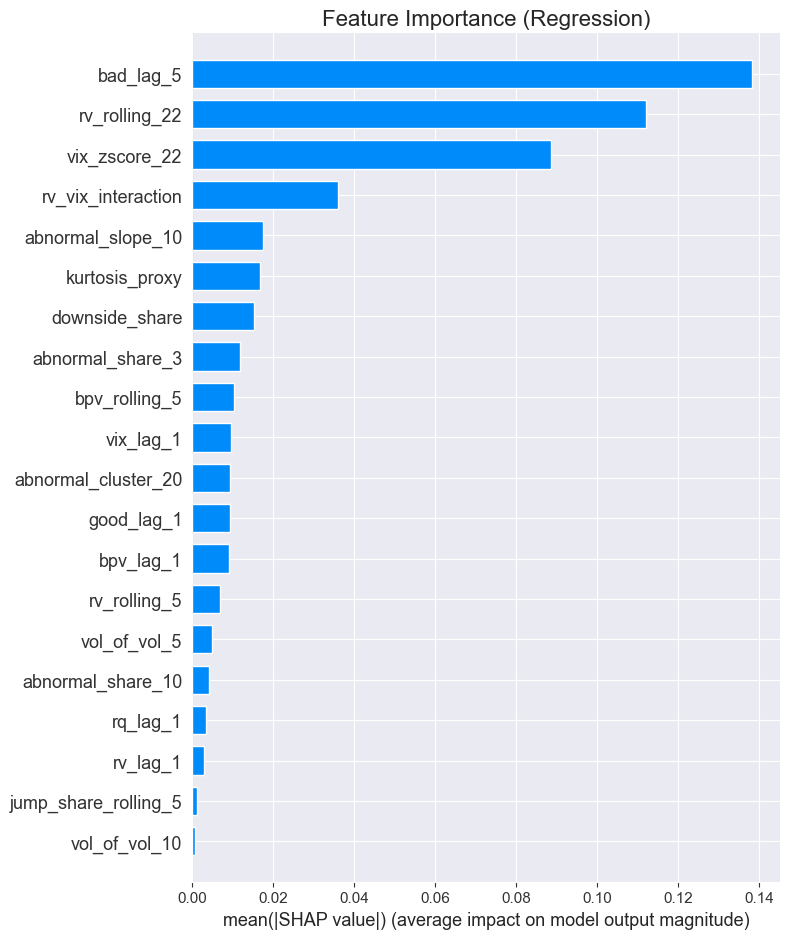

  Plotting Regression SHAP Summary...


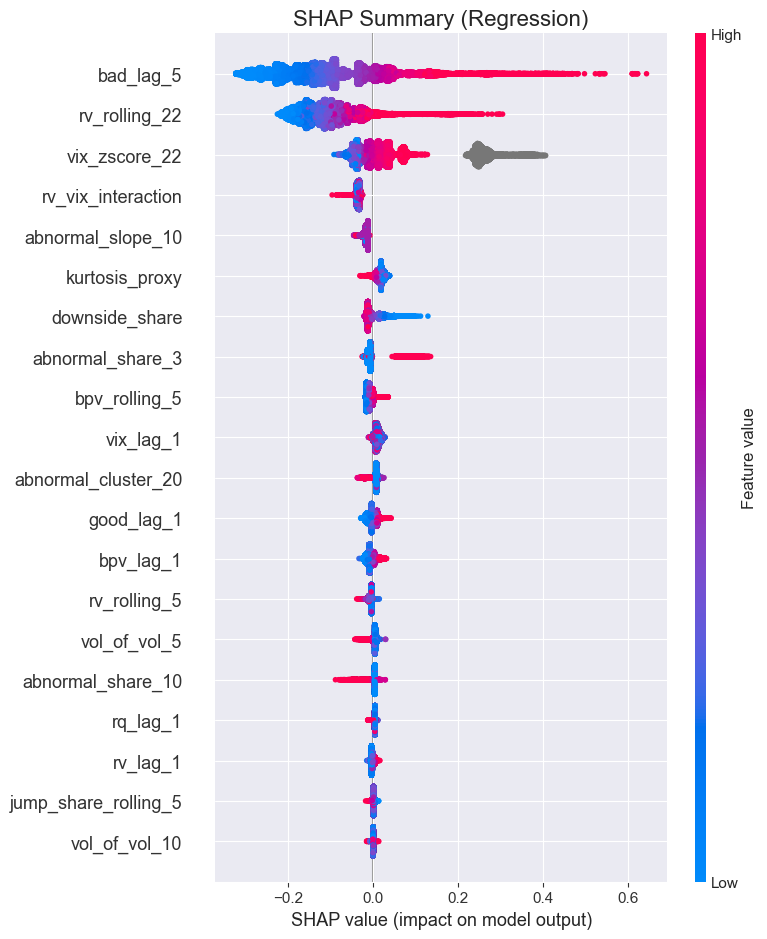


  Calculating SHAP for XGBClassifier (Final Fold)...
  Plotting Classification Feature Importance...


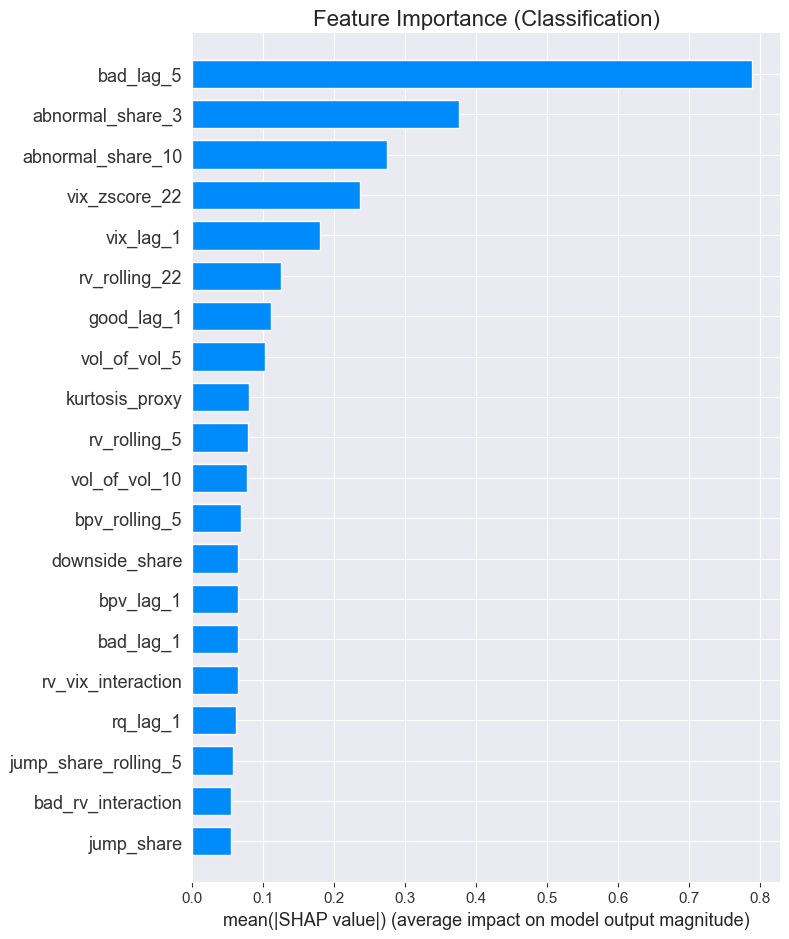

  Plotting Classification SHAP Summary...


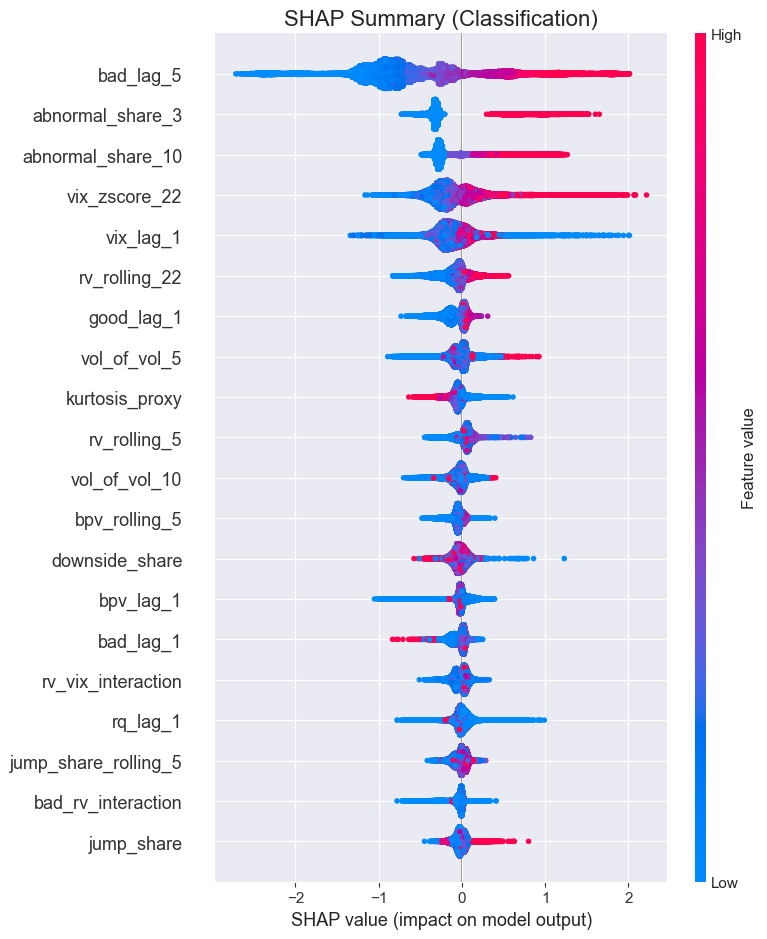

In [168]:
print("\n--- Starting Task 4.3: Model Interpretation (SHAP) ---")
print("  Calculating SHAP for XGBRegressor (Final Fold)...")

final_xgb_reg = xgb_reg_models[-1]
_, test_index_reg = list(tscv.split(X_advanced_log))[-1]
X_test_reg = X_advanced_log.iloc[test_index_reg]

explainer_reg = shap.TreeExplainer(final_xgb_reg)
shap_values_reg = explainer_reg(X_test_reg)

print("  Plotting Regression Feature Importance...")
plt.title('Feature Importance (Regression)', fontsize=16)
shap.summary_plot(shap_values_reg, X_test_reg, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

print("  Plotting Regression SHAP Summary...")
plt.title('SHAP Summary (Regression)', fontsize=16)
shap.summary_plot(shap_values_reg, X_test_reg, show=False)
plt.tight_layout()
plt.show()


print("\n  Calculating SHAP for XGBClassifier (Final Fold)...")

final_xgb_class = xgb_class_models[-1]
X_test_class = last_fold_data['X_test']

explainer_class = shap.TreeExplainer(final_xgb_class)
shap_values_class = explainer_class(X_test_class)

print("  Plotting Classification Feature Importance...")
plt.title('Feature Importance (Classification)', fontsize=16)
shap.summary_plot(shap_values_class, X_test_class, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

print("  Plotting Classification SHAP Summary...")
plt.title('SHAP Summary (Classification)', fontsize=16)
shap.summary_plot(shap_values_class, X_test_class, show=False)
plt.tight_layout()
plt.show()